# Análisis CUDD (`plus_t`) y exploración del versionado

- **Celda 1 — evolución del build:** pool, memoria y **bpi_build** (pre-trim, diagnóstico). Configura `ENCODING`, `DATASET_NAME`, `CSV_FILE`.
- **Celda 2 — versionado:** tabla compacta y histogramas sobre el `.docs` packed64.
- **Celda 3 — resumen build:** métricas finales (incluye bpi_build pre-trim).
- **Celda 4 — EDD operativa:** ladder **bpi_edd** / **bpi_file** post-load → `plus_t_bpi_ladder.csv` (**métrica definitiva**).
- **Celda 5 — reordenamiento (100 MB):** barrido `optimize sweep` → gráfico **bpi_edd**, Δ% y **tiempo** (`TIMEOUT` en gris rayado).
- **Celda 6 — reordenamiento (2 GB):** misma lógica; pack `wiki_2gb_plus_t_bin`.
- **Celda 7 — reordenamiento (1 GB):** misma lógica; pack `wiki_1gb_plus_t_bin`.

Formato del log de build: `Paso, Total_Ints, Nodos_Pool, Bytes_CUDD, RSS_KB, Tiempo_s, bpi_build` (generado por `zdd_cudd_plus_t build u+t|log … none 0 <csv> 500`; `bpi_build` lo calcula `NzddBpi::compute()` en C++).

Logs de optimize (automáticos): `resultados_test/optimize_runs.csv` y `optimize_sweep_<pack>_<ts>.csv`.


--- INICIO ANÁLISIS CUDD ---
Dataset: wiki_2gb
Leyendo log: resultados_test/cudd_evolucion_2gb_plus_t.csv


/tmp/ipykernel_53319/2365272178.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


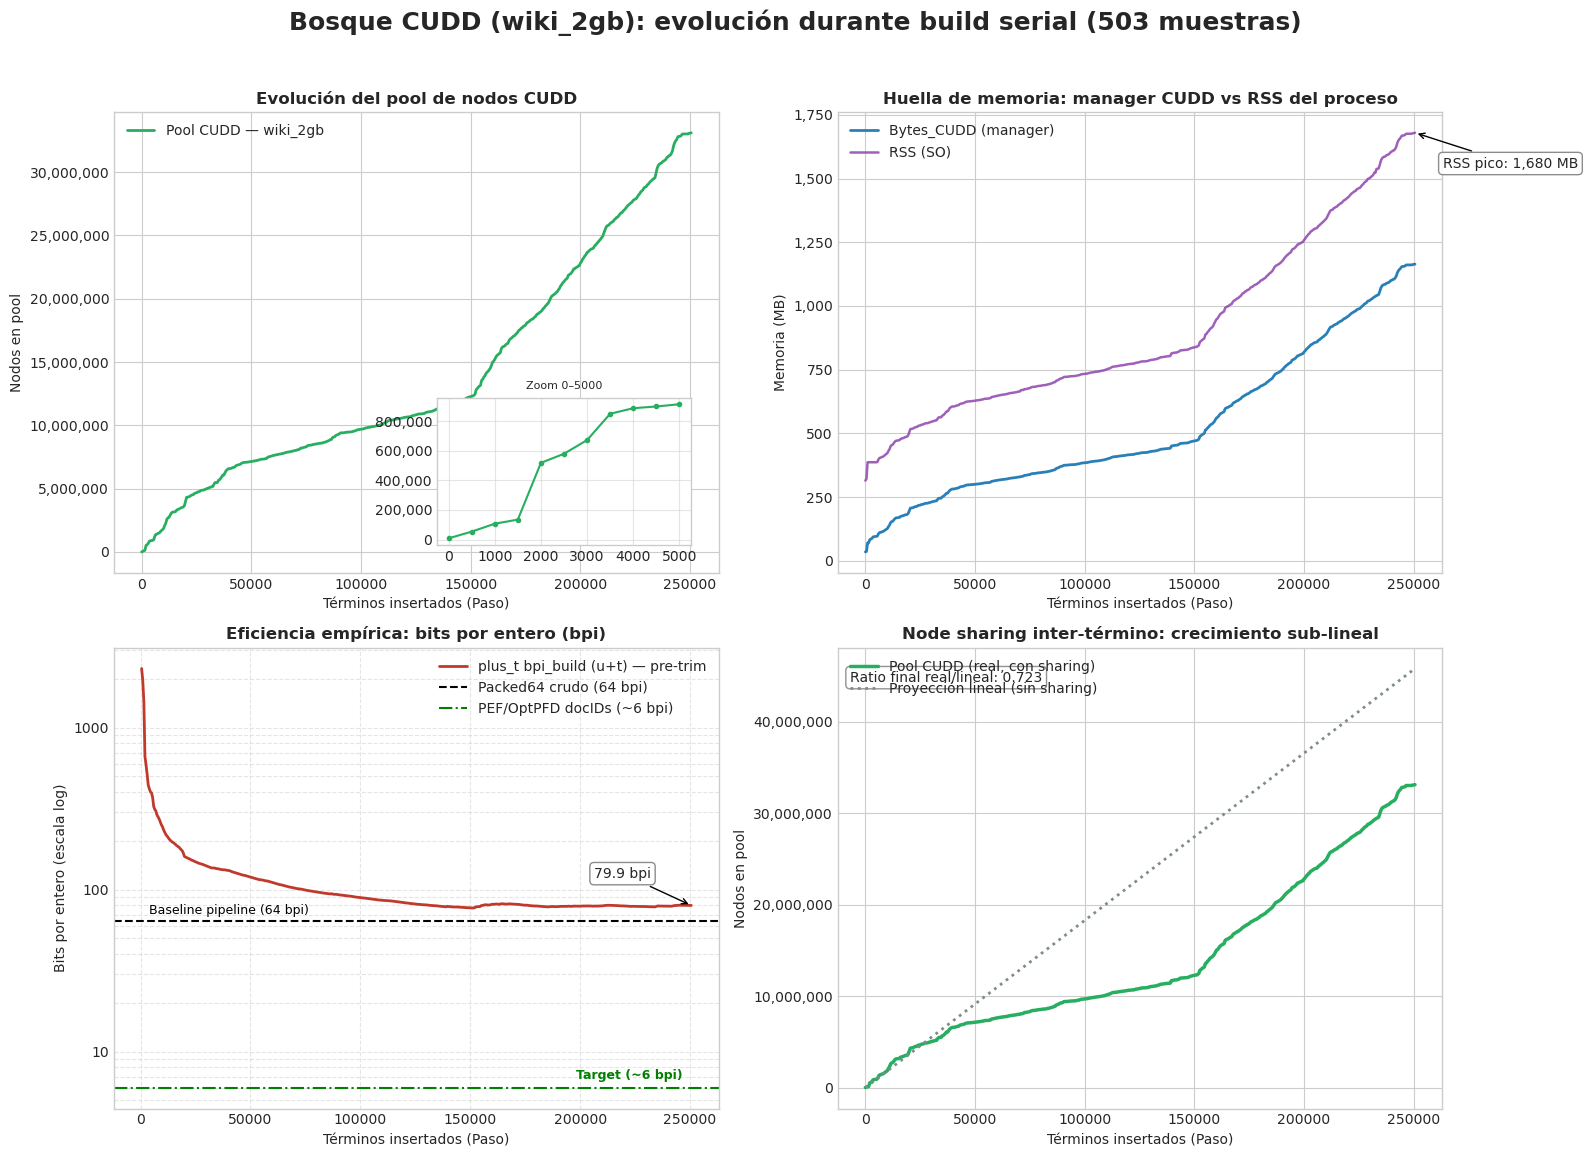

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display

# ==============================================================================
# 1. CONFIGURACIÓN
# ==============================================================================
ROOT = os.path.abspath('.')
if not os.path.isdir(os.path.join(ROOT, 'resultados_test')) and os.path.isdir(os.path.join(ROOT, '..', 'resultados_test')):
    ROOT = os.path.abspath('..')
os.chdir(ROOT)

OUTPUT_DIR = "resultados_test"

# Etiqueta para títulos/leyendas (independiente del nombre del CSV)
DATASET_NAME = "wiki_2gb"

# Codificación plus_t: "u+t" | "log"
ENCODING = "u+t"

# Log de evolución (zdd_cudd_plus_t build ENCODING … none 0 <csv> 500)
_suffix = "" if ENCODING == "u+t" else "_log"
_scale = {"wiki_100mb": "100mb", "wiki_1gb": "1gb", "wiki_2gb": "2gb"}.get(DATASET_NAME, DATASET_NAME.replace("wiki_", ""))
CSV_FILE = f"cudd_evolucion_{_scale}_plus_t{_suffix}.csv"

CSV_PATH = os.path.join(OUTPUT_DIR, CSV_FILE)

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"No se encontró el CSV: {CSV_PATH}")

print("--- INICIO ANÁLISIS CUDD ---")
print(f"Dataset: {DATASET_NAME}")
print(f"Leyendo log: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

# ==============================================================================
# 2. MÉTRICAS DERIVADAS (bpi_build viene del CSV; fallback solo para logs viejos)
# ==============================================================================
if 'bpi_build' in df.columns:
    df['bpi'] = df['bpi_build']
else:
    df['bpi'] = np.where(df['Total_Ints'] > 0, (df['Bytes_CUDD'] * 8) / df['Total_Ints'], np.nan)
    print('[AVISO] CSV sin columna bpi_build; usando fallback Python (regenerar build log)')
df['Bytes_Por_Nodo'] = np.where(df['Nodos_Pool'] > 0, df['Bytes_CUDD'] / df['Nodos_Pool'], np.nan)
df['MB_CUDD'] = df['Bytes_CUDD'] / (1024 * 1024)
df['MB_RSS'] = df['RSS_KB'] / 1024

# ==============================================================================
# 3. GRAFICACIÓN (estilo analisis.ipynb)
# ==============================================================================
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

C_POOL = '#27ae60'
C_MEM_CUDD, C_MEM_RSS = '#2980b9', '#8e44ad'
C_BPI, C_THEORY = '#c0392b', '#7f8c8d'
C_DENS = '#16a085'

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Bosque CUDD ({DATASET_NAME}): evolución durante build serial ({len(df)} muestras)',
    fontsize=18, fontweight='bold', y=0.98,
)
fmt_miles = ticker.StrMethodFormatter('{x:,.0f}')

# --- GRÁFICO 1: NODOS POOL ---
ax1 = axs[0, 0]
ax1.plot(df['Paso'], df['Nodos_Pool'], color=C_POOL, linewidth=2, label=f'Pool CUDD — {DATASET_NAME}')
ax1.set_title('Evolución del pool de nodos CUDD', fontsize=12, fontweight='bold')
ax1.set_xlabel('Términos insertados (Paso)')
ax1.set_ylabel('Nodos en pool')
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(fmt_miles)

pasos_zoom = int(min(5000, df['Paso'].max() * 0.05))
if pasos_zoom < 100:
    pasos_zoom = int(min(100, len(df) - 1))
zoom_mask = df['Paso'] <= pasos_zoom
if zoom_mask.any():
    axins1 = inset_axes(ax1, width="42%", height="32%", loc='lower right', borderpad=2)
    axins1.plot(df.loc[zoom_mask, 'Paso'], df.loc[zoom_mask, 'Nodos_Pool'], color=C_POOL, marker='.')
    axins1.set_title(f'Zoom 0–{pasos_zoom}', fontsize=8)
    axins1.grid(True, alpha=0.5)
    axins1.yaxis.set_major_formatter(fmt_miles)

# --- GRÁFICO 2: MEMORIA ---
ax2 = axs[0, 1]
ax2.plot(df['Paso'], df['MB_CUDD'], color=C_MEM_CUDD, linewidth=2, label='Bytes_CUDD (manager)')
ax2.plot(df['Paso'], df['MB_RSS'], color=C_MEM_RSS, linewidth=1.8, alpha=0.85, label='RSS (SO)')
ax2.set_title('Huella de memoria: manager CUDD vs RSS del proceso', fontsize=12, fontweight='bold')
ax2.set_xlabel('Términos insertados (Paso)')
ax2.set_ylabel('Memoria (MB)')
ax2.legend(loc='upper left')
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

peak_rss_mb = df['MB_RSS'].max()
ax2.annotate(
    f'RSS pico: {peak_rss_mb:,.0f} MB',
    xy=(df.loc[df['MB_RSS'].idxmax(), 'Paso'], peak_rss_mb),
    xytext=(20, -25), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9),
)

# --- GRÁFICO 3: BPI ---
ax3 = axs[1, 0]
ax3.semilogy(df['Paso'], df['bpi'], color=C_BPI, linewidth=2, label=f'plus_t bpi_build ({ENCODING}) — pre-trim')
ax3.axhline(y=64, color='black', linestyle='--', linewidth=1.5, label='Packed64 crudo (64 bpi)')
ax3.text(df['Paso'].iloc[0], 68, '  Baseline pipeline (64 bpi)', color='black', va='bottom', fontsize=9)
ax3.axhline(y=6, color='green', linestyle='-.', linewidth=1.5, label='PEF/OptPFD docIDs (~6 bpi)')
ax3.text(df['Paso'].iloc[-1], 6.5, 'Target (~6 bpi)  ', color='green', va='bottom', ha='right', fontsize=9, fontweight='bold')
ax3.set_title('Eficiencia empírica: bits por entero (bpi)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Términos insertados (Paso)')
ax3.set_ylabel('Bits por entero (escala log)')
ax3.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax3.grid(True, which='both', linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

final_bpi = df['bpi'].iloc[-1]
ax3.annotate(
    f'{final_bpi:.1f} bpi',
    xy=(df['Paso'].iloc[-1], final_bpi),
    xytext=(-70, 20), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9),
)

# --- GRÁFICO 4: SUBLINEALIDAD ---
ax4 = axs[1, 1]
base_idx = min(10, len(df) - 1)
if df['Paso'].iloc[base_idx] > 0:
    slope = df['Nodos_Pool'].iloc[base_idx] / df['Paso'].iloc[base_idx]
else:
    slope = 1.0
linear_proj = df['Paso'] * slope
ax4.plot(df['Paso'], df['Nodos_Pool'], color=C_POOL, linewidth=2.5, label='Pool CUDD (real, con sharing)')
ax4.plot(df['Paso'], linear_proj, color=C_THEORY, linestyle=':', linewidth=2, label='Proyección lineal (sin sharing)')
ax4.set_title('Node sharing inter-término: crecimiento sub-lineal', fontsize=12, fontweight='bold')
ax4.set_xlabel('Términos insertados (Paso)')
ax4.set_ylabel('Nodos en pool')
ax4.legend(loc='upper left')
ax4.yaxis.set_major_formatter(fmt_miles)

ratio = df['Nodos_Pool'].iloc[-1] / linear_proj.iloc[-1] if linear_proj.iloc[-1] > 0 else np.nan
ax4.text(
    0.02, 0.95,
    f'Ratio final real/lineal: {ratio:.3f}',
    transform=ax4.transAxes, fontsize=10,
    bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85),
    va='top',
)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()



--- EXPLORATORIO VERSIONADO: wiki_2gb ---
terminos=250,550 (250,550 no vacíos) | master_global_distinto=4,327 | rel_global_distinto=4,043 | posting_global_distinta=149,761 | postings_totales=122,197,799 | 63.4s
snapshots_totales=1,692,450 | snapshots_unicos_global=987,298 | reuso_cruzado=1.71×
rel=versión relativa | master=docglobal | snapshot S_i^v=conjunto de masters por rel | ZDD^t=F_t∪{tag}
Ratios: snapshots/rel=0.0330 | rel/snapshot=30.31× | postings_totales/posting_global_distinta=815.95×


,min,mean,p50,p90,max
rel por término,1.00,204.72,19.00,523.00,"4,042.00"
snapshots por término (|F_t|),1.00,6.75,1.00,9.00,575.00
|S_i^v| tamaño snapshot,1.00,19.29,6.00,44.00,"3,511.00"
|ZDD^t| = |F_t|+1,2.00,7.75,2.00,10.00,576.00
master por término,1.00,7.18,1.00,7.00,"4,222.00"
rel/master dentro del término (prom.),1.00,66.97,15.00,152.20,"3,578.00"
rel por docglobal,1.00,34.61,9.00,59.00,"4,043.00"
términos por docglobal,14.00,415.51,241.00,868.00,"13,144.00"


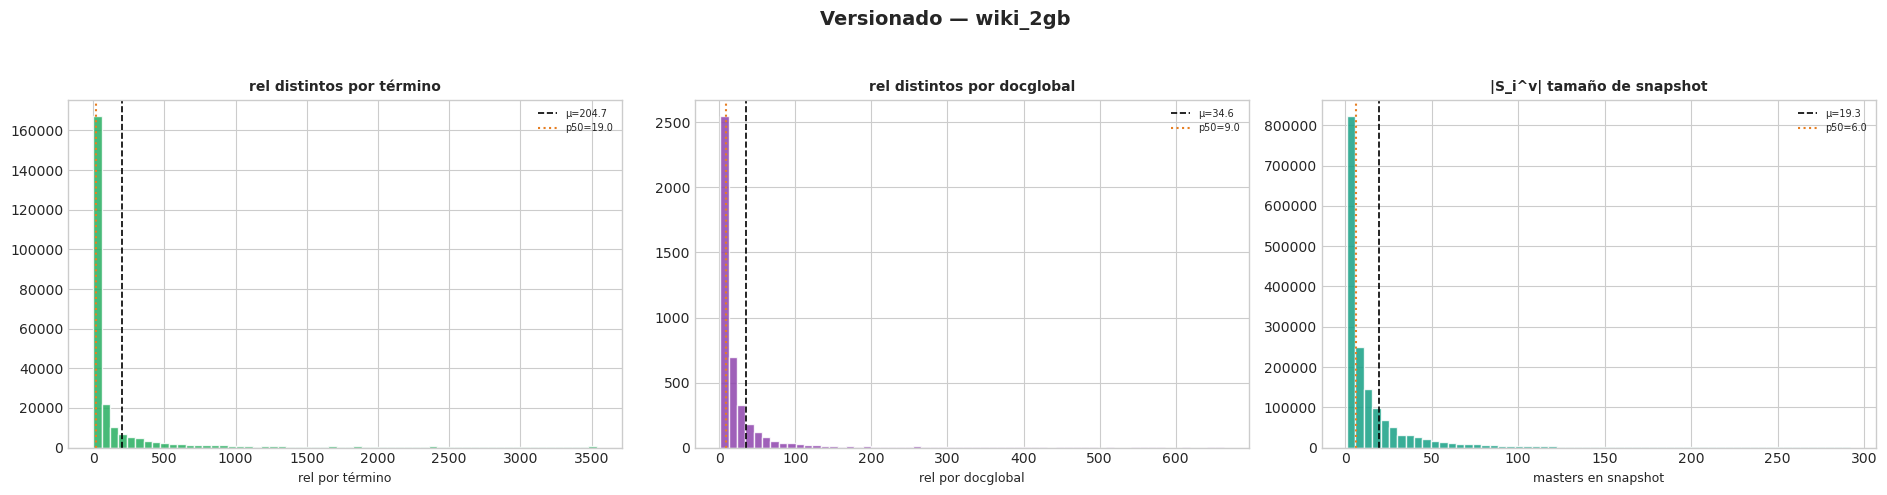

In [2]:
# ==============================================================================
# 2. EXPLORATORIO VERSIONADO — .docs packed64 (master | rel)
# ==============================================================================
import struct
import time
from collections import defaultdict

# --- Parámetros (alinear con DATASET_NAME de la celda anterior) ---
VERSION_DATASET = DATASET_NAME
DOCS_PATH = os.path.join(OUTPUT_DIR, f"{VERSION_DATASET}_uihrdc_packed64.docs")
DOCS_PATH = DOCS_PATH if os.path.exists(DOCS_PATH) else os.path.join(
    OUTPUT_DIR, f"{VERSION_DATASET}_uihrdc_packed.docs"
)
REL_BITS = 24
MAX_TERMS = 0          # 0 = todos los términos
HIST_BINS = 60

REL_MASK = (1 << REL_BITS) - 1


def unpack_master(packed: int) -> int:
    return packed >> REL_BITS


def unpack_rel(packed: int) -> int:
    return packed & REL_MASK


def iter_docs_postings(path: str, max_terms: int = 0):
    with open(path, "rb") as f:
        (nlists,) = struct.unpack("<I", f.read(4))
        limit = nlists if max_terms <= 0 else min(nlists, max_terms)
        for term_id in range(limit):
            (length,) = struct.unpack("<I", f.read(4))
            if length == 0:
                yield term_id, ()
                continue
            raw = f.read(8 * length)
            postings = struct.unpack(f"<{length}Q", raw)
            yield term_id, postings


def version_stats_from_postings(postings):
    """rel distintos, snapshots dedup (F_t), tamaños |S_i^v| y hashes para reuso cruzado."""
    if not postings:
        return 0, 0, 0, 0, 0.0, {}, [], set()

    rel_master_masks = defaultdict(int)
    master_rel_masks = defaultdict(int)
    for packed in postings:
        master = unpack_master(packed)
        rel = unpack_rel(packed)
        rel_master_masks[rel] |= 1 << master
        master_rel_masks[master] |= 1 << rel

    rels_per_master = [mask.bit_count() for mask in master_rel_masks.values()]
    unique_snapshots = set(rel_master_masks.values())
    snapshot_sizes = [mask.bit_count() for mask in unique_snapshots]
    snapshot_hashes = {hash(mask) for mask in unique_snapshots}

    n_postings = len(postings)
    n_rel = len(rel_master_masks)
    n_snapshots = len(unique_snapshots)
    n_masters = len(master_rel_masks)
    avg_rel_per_master = float(np.mean(rels_per_master))
    return (
        n_postings,
        n_rel,
        n_snapshots,
        n_masters,
        avg_rel_per_master,
        master_rel_masks,
        snapshot_sizes,
        snapshot_hashes,
    )


def compact_stats(series: pd.Series) -> pd.Series:
    s = series.dropna()
    if s.empty:
        return pd.Series(dtype=float)
    return pd.Series(
        {
            "min": s.min(),
            "mean": s.mean(),
            "p50": s.median(),
            "p90": s.quantile(0.90),
            "max": s.max(),
        }
    )


def hist_metric(ax, series, title, color, xlabel=None):
    vals = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    if vals.empty:
        ax.set_visible(False)
        return
    upper = np.percentile(vals, 99.5)
    clipped = vals[vals <= upper]
    ax.hist(clipped, bins=HIST_BINS, color=color, alpha=0.85, edgecolor="white")
    ax.set_title(title, fontweight="bold", fontsize=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9)
    ax.axvline(vals.mean(), color="black", linestyle="--", lw=1.2, label=f"μ={vals.mean():.1f}")
    ax.axvline(vals.median(), color="#e67e22", linestyle=":", lw=1.5, label=f"p50={vals.median():.1f}")
    ax.legend(fontsize=7)


if not os.path.exists(DOCS_PATH):
    raise FileNotFoundError(f"No se encontró .docs: {DOCS_PATH}")

t0 = time.perf_counter()
term_rows = []
master_term_count = defaultdict(int)
master_rel_masks = defaultdict(int)
master_sum_rel_per_term = defaultdict(int)
postings_totales = 0
snapshot_sizes_all = []
snapshots_global_hashes = set()
snapshots_totales = 0

for term_id, postings in iter_docs_postings(DOCS_PATH, MAX_TERMS):
    (
        n_post,
        n_rel,
        n_snap,
        n_mast,
        avg_rel_master,
        term_master_rel_masks,
        snapshot_sizes,
        snapshot_hashes,
    ) = version_stats_from_postings(postings)

    term_rows.append(
        {
            "n_postings": n_post,
            "n_rel": n_rel,
            "n_snapshots": n_snap,
            "n_masters": n_mast,
            "avg_rel_per_master": avg_rel_master,
            "n_zdd_cardinality": n_snap + 1,  # |ZDD^t| = |F_t| + 1 (tag)
        }
    )
    postings_totales += n_post
    snapshot_sizes_all.extend(snapshot_sizes)
    snapshots_global_hashes.update(snapshot_hashes)
    snapshots_totales += n_snap
    for master, rel_mask in term_master_rel_masks.items():
        n_master_rel = rel_mask.bit_count()
        master_term_count[master] += 1
        master_rel_masks[master] |= rel_mask
        master_sum_rel_per_term[master] += n_master_rel

elapsed = time.perf_counter() - t0
term_df = pd.DataFrame(term_rows)
master_df = pd.DataFrame(
    [
        {
            "n_terms": master_term_count[master],
            "n_rel": rel_mask.bit_count(),
            "avg_rel_per_term": (
                master_sum_rel_per_term[master] / master_term_count[master]
            ),
        }
        for master, rel_mask in master_rel_masks.items()
    ]
)

non_empty = term_df[term_df["n_postings"] > 0].copy()
terminos = len(term_df)
master_global_distinto = len(master_df)
posting_global_distinta = int(master_df["n_rel"].sum())
rel_global_mask = 0
for rel_mask in master_rel_masks.values():
    rel_global_mask |= rel_mask
rel_global_distinto = rel_global_mask.bit_count()
snapshots_unicos_global = len(snapshots_global_hashes)

global_snapshots_per_rel = (
    non_empty["n_snapshots"].sum() / max(non_empty["n_rel"].sum(), 1)
)
global_rel_per_snapshot = (
    non_empty["n_rel"].sum() / max(non_empty["n_snapshots"].sum(), 1)
)
snapshot_reuse_cross_term = snapshots_totales / max(snapshots_unicos_global, 1)

snapshot_size_series = pd.Series(snapshot_sizes_all, dtype=float)

summary = pd.DataFrame(
    {
        "rel por término": compact_stats(non_empty["n_rel"]),
        "snapshots por término (|F_t|)": compact_stats(non_empty["n_snapshots"]),
        "|S_i^v| tamaño snapshot": compact_stats(snapshot_size_series),
        "|ZDD^t| = |F_t|+1": compact_stats(non_empty["n_zdd_cardinality"]),
        "master por término": compact_stats(non_empty["n_masters"]),
        "rel/master dentro del término (prom.)": compact_stats(
            non_empty["avg_rel_per_master"]
        ),
        "rel por docglobal": compact_stats(master_df["n_rel"]),
        "términos por docglobal": compact_stats(master_df["n_terms"]),
    }
).T

# ---- Conteos globales del .docs ----
# terminos: vocabulario = posting lists (término → lista es 1:1).
# postings_totales: entradas (master, rel) contando repetición entre términos (= Total_Ints).
# master_global_distinto: docglobals (master_id) únicos que aparecen (≠ universo U = 2^40).
# posting_global_distinta: pares (master, rel) únicos en todo el corpus.
# rel_global_distinto: enteros rel distintos observados (ignora a qué master pertenecen).
# snapshots_totales: suma de |F_t| deduplicados por término.
# snapshots_unicos_global: snapshots distintos cruzando todos los términos (hash del bitset).
print(f"--- EXPLORATORIO VERSIONADO: {VERSION_DATASET} ---")
print(
    f"terminos={terminos:,} ({len(non_empty):,} no vacíos) | "
    f"master_global_distinto={master_global_distinto:,} | "
    f"rel_global_distinto={rel_global_distinto:,} | "
    f"posting_global_distinta={posting_global_distinta:,} | "
    f"postings_totales={postings_totales:,} | {elapsed:.1f}s"
)
print(
    f"snapshots_totales={snapshots_totales:,} | "
    f"snapshots_unicos_global={snapshots_unicos_global:,} | "
    f"reuso_cruzado={snapshot_reuse_cross_term:,.2f}×"
)
print("rel=versión relativa | master=docglobal | snapshot S_i^v=conjunto de masters por rel | ZDD^t=F_t∪{tag}")
print(
    f"Ratios: snapshots/rel={global_snapshots_per_rel:.4f} | "
    f"rel/snapshot={global_rel_per_snapshot:,.2f}× | "
    f"postings_totales/posting_global_distinta={postings_totales / max(posting_global_distinta, 1):,.2f}×"
)

display(
    summary.style.format("{:,.2f}", na_rep="—")
    .background_gradient(cmap="YlGnBu", axis=1)
    .set_caption(f"Versionado — análisis exploratorio ({VERSION_DATASET})")
)

fig_v, axs_v = plt.subplots(1, 3, figsize=(19, 5))
fig_v.suptitle(
    f"Versionado — {VERSION_DATASET}",
    fontsize=14,
    fontweight="bold",
)
hist_metric(axs_v[0], non_empty["n_rel"], "rel distintos por término", C_POOL, "rel por término")
hist_metric(axs_v[1], master_df["n_rel"], "rel distintos por docglobal", "#8e44ad", "rel por docglobal")
hist_metric(
    axs_v[2],
    snapshot_size_series,
    "|S_i^v| tamaño de snapshot",
    C_DENS,
    "masters en snapshot",
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


In [3]:
# ==============================================================================
# 3. TABLA RESUMEN
# ==============================================================================

final = df.iloc[-1]

resumen_rows = [
    {
        'Métrica': 'Dataset',
        'Valor': DATASET_NAME,
    },
    {
        'Métrica': 'Log CSV',
        'Valor': CSV_FILE,
    },
    {
        'Métrica': 'Términos (Paso final)',
        'Valor': f"{int(final['Paso']):,}",
    },
    {
        'Métrica': 'Total enteros indexados',
        'Valor': f"{int(final['Total_Ints']):,}",
    },
    {
        'Métrica': 'Nodos pool CUDD (final build)',
        'Valor': f"{int(final['Nodos_Pool']):,}",
    },
    {
        'Métrica': 'Bytes CUDD manager (final)',
        'Valor': f"{int(final['Bytes_CUDD']):,} ({final['Bytes_CUDD']/1024/1024:.1f} MB)",
    },
    {
        'Métrica': 'RSS pico (SO)',
        'Valor': f"{int(df['RSS_KB'].max()):,} KB ({df['RSS_KB'].max()/1024:.1f} MB)",
    },
    {
        'Métrica': 'Tiempo build (final log)',
        'Valor': f"{final['Tiempo_s']:.2f} s",
    },
    {
        'Métrica': 'bpi_build pre-trim (Bytes_CUDD×8 / Total_Ints)',
        'Valor': f"{final['bpi']:.2f} bpi  → ver celda 4 para bpi_mem (EDD operativa)",
    },
]

resumen = pd.DataFrame(resumen_rows)

print(f'\n=== RESUMEN CUDD — {DATASET_NAME} ===')
display(resumen.style.hide(axis='index'))




=== RESUMEN CUDD — wiki_2gb ===


Métrica,Valor
Dataset,wiki_2gb
Log CSV,cudd_evolucion_2gb_plus_t.csv
Términos (Paso final),"250,550"
Total enteros indexados,"122,197,799"
Nodos pool CUDD (final build),"33,108,908"
Bytes CUDD manager (final),"1,220,601,512 (1164.1 MB)"
RSS pico (SO),"1,719,924 KB (1679.6 MB)"
Tiempo build (final log),38.50 s
bpi_build pre-trim (Bytes_CUDD×8 / Total_Ints),79.91 bpi → ver celda 4 para bpi_mem (EDD operativa)


Mediciones guardadas: resultados_test/plus_t_bpi_ladder.csv
(Comparativa histórica BB1: resultados_test/edd_bpi_ladder.csv — no se sobrescribe)


,dataset,variant,total_ints,bpi_edd,bpi_file,bpi_mem,edd_nodes,edd_mb,file_mb,mem_mb,overhead_pct
0,100 MB,plus_t u+t,"5,424,820",0.51,0.43,18.01,"10,785",0.33,0.28,11.65,97.2 %
1,100 MB,plus_t log,"5,424,820",0.74,0.58,16.58,"15,671",0.48,0.37,10.72,95.5 %
2,1 GB,plus_t u+t,"61,447,986",21.34,13.49,36.49,"5,122,669",156.33,98.84,267.28,41.5 %
3,1 GB,plus_t log,"61,447,986",21.65,13.69,30.25,"5,196,664",158.59,100.25,221.59,28.4 %
4,2 GB,plus_t u+t,"122,197,799",35.21,22.14,47.06,"16,806,291",512.89,322.47,685.51,25.2 %
5,2 GB,plus_t log,"122,197,799",35.47,22.30,45.42,"16,931,565",516.71,324.86,661.65,21.9 %



bpi_edd es la métrica de la EDD. bpi_mem se muestra sólo como diagnóstico:
la columna overhead_pct indica qué fracción de Cudd_ReadMemoryInUse es
andamiaje del manager (caché, subtablas, slots, univ, nodos muertos).


Gráfico guardado: resultados_test/plus_t_bpi_ladder.png


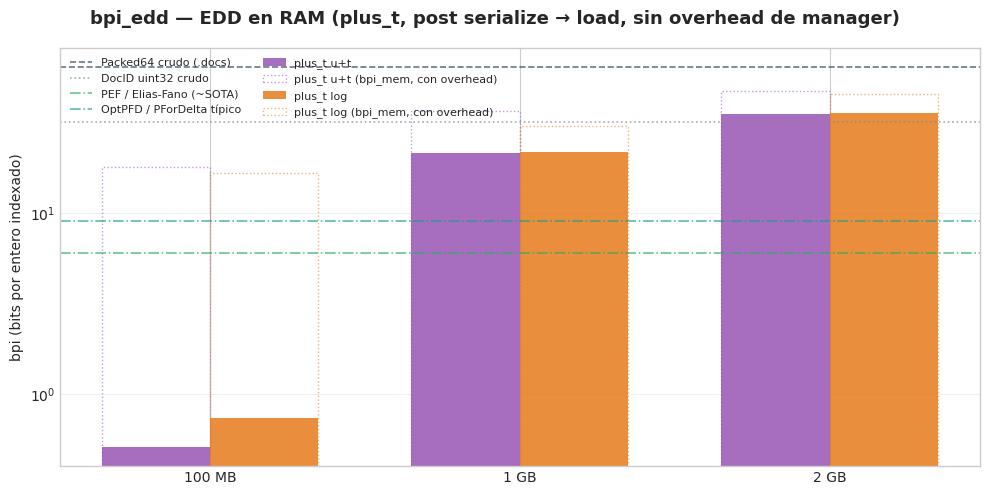

In [4]:
# ==============================================================================
# 4. BPI EDD operativa — ladder plus_t
#    bpi_edd  = nodos del DAG × sizeof(DdNode) × 8 / N   ← PRINCIPAL (RAM)
#    bpi_file = |.zpack| × 8 / N                            disco
#    bpi_mem  = Cudd_ReadMemoryInUse × 8 / N                DIAGNÓSTICO
#
# bpi_mem incluye caché, subtablas, slots de hash, cadena univ y nodos muertos
# del manager CUDD: en wiki_100mb eso es el 97% del total. Se conserva sólo para
# dimensionar el proceso completo, no como tamaño de la EDD.
#
# Cotas de encoding del mismo DAG (derivadas de edd_nodes y numZddVars, no
# medidas). De más laxa a más estricta:
#    bpi_zdd_std       ZDD estándar de la literatura: 2N⌈log₂(N+1)⌉ + N⌈log₂(V+1)⌉
#    bpi_level_grouped nodos agrupados por nivel: 2N⌈log₂(N+1)⌉ + V⌈log₂(N+1)⌉
#    bpi_dag_counting  piso information-theoretic: 2·log₂((N+1)!) + V⌈log₂(N+1)⌉
#
# bpi_zdd_std NO es una cota inferior: es la línea base contra la que compiten
# DenseZDD y Top ZDD, que quedan por debajo. Ver docs/METRICAS_LATEX.md.
# ==============================================================================
import subprocess
import re
from pathlib import Path
from IPython.display import Image, display

MEASURE_BIN = Path('scripts/measure_zpack_bpi')
MEASURE_COMPILE = (
    f'g++ -O2 -std=c++17 -o {MEASURE_BIN} scripts/measure_zpack_bpi.cpp '
    '-I . -I ./TdZdd/include -I ./cudd -I ./cudd/cudd '
    '-I ./cudd/st -I ./cudd/util -I ./cudd/mtr -I ./cudd/epd '
    "-L ./cudd/cudd/.libs -Wl,-rpath,'$ORIGIN/../cudd/cudd/.libs' -lcudd"
)
if not MEASURE_BIN.exists():
    raise FileNotFoundError(f'Compilar primero: {MEASURE_COMPILE}')

LD_PATH = str(Path('cudd/cudd/.libs').resolve())

LADDER = [
    {
        'dataset': 'wiki_100mb',
        'label': '100 MB',
        'docs': OUTPUT_DIR + '/wiki_100mb_uihrdc_packed64.docs',
        'packs': {
            'plus_t u+t': [
                OUTPUT_DIR + '/wiki_100mb_plus_t.zpack',
            ],
            'plus_t log': [
                OUTPUT_DIR + '/wiki_100mb_plus_t_log.zpack',
                OUTPUT_DIR + '/wiki_100mb_plus_t_bin_tmp.zpack',  # legacy
            ],
        },
    },
    {
        'dataset': 'wiki_1gb',
        'label': '1 GB',
        'docs': OUTPUT_DIR + '/wiki_1gb_uihrdc_packed64.docs',
        'packs': {
            'plus_t u+t': [OUTPUT_DIR + '/wiki_1gb_plus_t.zpack'],
            'plus_t log': [
                OUTPUT_DIR + '/wiki_1gb_plus_t_log.zpack',
                OUTPUT_DIR + '/wiki_1gb_plus_t_bin.zpack',  # legacy
            ],
        },
    },
    {
        'dataset': 'wiki_2gb',
        'label': '2 GB',
        'docs': OUTPUT_DIR + '/wiki_2gb_uihrdc_packed64.docs',
        'packs': {
            'plus_t u+t': [OUTPUT_DIR + '/wiki_2gb_plus_t.zpack'],
            'plus_t log': [
                OUTPUT_DIR + '/wiki_2gb_plus_t_log.zpack',
                OUTPUT_DIR + '/wiki_2gb_plus_t_bin.zpack',  # legacy
            ],
        },
    },
]

SOTA_LINES = [
    ('Packed64 crudo (.docs)', 64, '#2c3e50', '--'),
    ('DocID uint32 crudo', 32, '#7f8c8d', ':'),
    ('PEF / Elias-Fano (~SOTA)', 6, '#27ae60', '-.'),
    ('OptPFD / PForDelta típico', 9, '#16a085', '-.'),
]

PAT = re.compile(r'^([a-z_]+)=(.+)$')


def resolve_pack(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p, ('legacy' if '_bin' in os.path.basename(p) else 'canonical')
    return None, None


def measure_pack(pack_path: str, docs_path: str) -> dict:
    env = os.environ.copy()
    env['LD_LIBRARY_PATH'] = LD_PATH + (':' + env['LD_LIBRARY_PATH'] if env.get('LD_LIBRARY_PATH') else '')
    out = subprocess.check_output([str(MEASURE_BIN), pack_path, docs_path], text=True, env=env)
    metrics = {}
    for line in out.splitlines():
        m = PAT.match(line.strip())
        if not m:
            continue
        key, val = m.group(1), m.group(2)
        if key in {
            'total_ints', 'terms_scanned', 'terms_measured', 'pool_nodes', 'file_bytes', 'numZddVars', 'docOffset',
            'edd_nodes', 'bytes_edd', 'bytes_cudd', 'bytes_overhead', 'node_bytes',
            'univ_nodes', 'dead_nodes', 'bytes_cache', 'bytes_subtables', 'bytes_hash_slots',
            'n_raw', 'n_pairs_uniq', 'n_snap_elems', 'n_masters_uniq', 'snapshots_distinct',
        }:
            metrics[key] = int(float(val))
        elif key in {
            'bpi_edd', 'bpi_mem', 'bpi_file', 'overhead_pct',
            'bpi_edd_min', 'bpi_edd_over_stored', 'bpi_edd_min_over_stored',
            'bpi_zdd_std', 'bpi_level_grouped', 'bpi_dag_counting',
            'bpi_zdd_std_over_stored',
            'bits_per_node_zdd_std', 'bits_per_node_level_grouped',
            'bits_per_node_counting',
            'ratio_raw_over_stored', 'compression_vs_raw', 'bits_per_stored_elem',
        }:
            metrics[key] = float(val)
    return metrics


rows = []
for entry in LADDER:
    docs = entry['docs']
    if not os.path.exists(docs):
        print(f"[SKIP] falta {docs}")
        continue
    for variant, candidates in entry['packs'].items():
        pack, naming = resolve_pack(candidates)
        if not pack:
            print(f"[AVISO] {entry['label']} / {variant}: sin .zpack — omitido")
            continue
        m = measure_pack(pack, docs)
        rows.append({
            'dataset': entry['label'],
            'variant': variant,
            'pack_path': pack,
            'naming': naming,
            'terms_measured': int(m.get('terms_measured', m.get('total_ints', 0))),
            'total_ints': int(m['total_ints']),
            'bpi_edd': m['bpi_edd'],
            'bpi_file': m['bpi_file'],
            'bpi_mem': m['bpi_mem'],
            'bpi_zdd_std': m.get('bpi_zdd_std', m.get('bpi_edd_min', np.nan)),
            'bpi_level_grouped': m.get('bpi_level_grouped', np.nan),
            'bpi_dag_counting': m.get('bpi_dag_counting', np.nan),
            'bpn_zdd_std': m.get('bits_per_node_zdd_std', np.nan),
            'bpn_level_grouped': m.get('bits_per_node_level_grouped', np.nan),
            'bpn_counting': m.get('bits_per_node_counting', np.nan),
            'bpi_edd_over_stored': m.get('bpi_edd_over_stored', np.nan),
            'ratio_raw_over_stored': m.get('ratio_raw_over_stored', np.nan),
            'edd_nodes': int(m['edd_nodes']),
            'edd_mb': m['bytes_edd'] / (1024 * 1024),
            'file_mb': m['file_bytes'] / (1024 * 1024),
            'mem_mb': m['bytes_cudd'] / (1024 * 1024),
            'overhead_pct': m['overhead_pct'],
            'pool_loaded': int(m['pool_nodes']),
            'univ_nodes': int(m['univ_nodes']),
            'dead_nodes': int(m['dead_nodes']),
            'cache_mb': m['bytes_cache'] / (1024 * 1024),
        })

if not rows:
    raise RuntimeError('No hay .zpack plus_t medibles. Ejecutar build en resultados_test/.')

edd = pd.DataFrame(rows)
plus_t_csv = os.path.join(OUTPUT_DIR, 'plus_t_bpi_ladder.csv')
edd.to_csv(plus_t_csv, index=False)
print(f'Mediciones guardadas: {plus_t_csv}')
print('(Comparativa histórica BB1: resultados_test/edd_bpi_ladder.csv — no se sobrescribe)')
display(edd[[
    'dataset', 'variant', 'total_ints', 'bpi_edd', 'bpi_file', 'bpi_mem',
    'bpi_zdd_std', 'bpi_level_grouped', 'bpi_dag_counting',
    'ratio_raw_over_stored', 'bpi_edd_over_stored',
    'edd_nodes', 'edd_mb', 'file_mb', 'mem_mb', 'overhead_pct',
]].style.format({
    'total_ints': '{:,.0f}',
    'bpi_edd': '{:.2f}',
    'bpi_zdd_std': '{:.2f}',
    'bpi_level_grouped': '{:.2f}',
    'bpi_dag_counting': '{:.2f}',
    'bpi_file': '{:.2f}',
    'bpi_mem': '{:.2f}',
    'ratio_raw_over_stored': '{:.1f}',
    'bpi_edd_over_stored': '{:.1f}',
    'edd_nodes': '{:,.0f}',
    'edd_mb': '{:.2f}',
    'file_mb': '{:.2f}',
    'mem_mb': '{:.2f}',
    'overhead_pct': '{:.1f} %',
}).background_gradient(subset=['bpi_edd'], cmap='YlOrRd'))

print(
    '\nbpi_edd es la métrica de la EDD. bpi_mem se muestra sólo como diagnóstico:\n'
    'la columna overhead_pct indica qué fracción de Cudd_ReadMemoryInUse es\n'
    'andamiaje del manager (caché, subtablas, slots, univ, nodos muertos).'
)

# --- Gráfico: bpi_edd (EDD real en RAM) ---
variants = ['plus_t u+t', 'plus_t log']
colors = {'plus_t u+t': '#9b59b6', 'plus_t log': '#e67e22'}
datasets = [e['label'] for e in LADDER if os.path.exists(e['docs'])]

fig_l, ax_l = plt.subplots(figsize=(10, 5))
fig_l.suptitle(
    'bpi_edd — EDD en RAM (plus_t, post serialize → load, sin overhead de manager)',
    fontsize=13, fontweight='bold',
)
x = np.arange(len(datasets))
width = 0.35
for i, variant in enumerate(variants):
    y, y_mem = [], []
    for d in datasets:
        sub = edd[(edd['dataset'] == d) & (edd['variant'] == variant)]
        y.append(sub['bpi_edd'].iloc[0] if len(sub) else np.nan)
        y_mem.append(sub['bpi_mem'].iloc[0] if len(sub) else np.nan)
    offset = (i - 0.5) * width
    ax_l.bar(x + offset, y, width, label=variant, color=colors[variant], alpha=0.88)
    # Contorno hueco: hasta dónde llegaba el bpi_mem que se reportaba antes.
    ax_l.bar(x + offset, y_mem, width, facecolor='none', edgecolor=colors[variant],
             linewidth=1.0, linestyle=':', alpha=0.6,
             label=f'{variant} (bpi_mem, con overhead)')

for label, yval, color, ls in SOTA_LINES:
    ax_l.axhline(y=yval, color=color, linestyle=ls, linewidth=1.2, alpha=0.7, label=label)

ax_l.set_xticks(x)
ax_l.set_xticklabels(datasets)
ax_l.set_ylabel('bpi (bits por entero indexado)')
ax_l.set_yscale('log')
ax_l.legend(loc='upper left', fontsize=8, ncol=2)
ax_l.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'plus_t_bpi_ladder.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
print(f'Gráfico guardado: {out_png}')
plt.show()


Sweep: resultados_test/optimize_sweep_wiki_100mb_plus_t_20260802_172326.csv
Heurísticas ok: 14  |  TIMEOUT: 0  |  baseline bpi_edd=0.5089


,heuristica,status,categoria,edd_before,edd_after,delta_pct,bpi_edd_after,delta_bpi_pct,seconds
0,baseline,ok,baseline,"10,785","10,785",0.00,0.5089,0.00,0.0
1,nodes_desc,ok,estática,"10,785","10,724",-0.57,0.5061,-0.57,0.0
2,df_desc,ok,estática,"10,785","10,873",0.82,0.5131,0.82,0.0
3,nodes_asc,ok,estática,"10,785","10,762",-0.21,0.5079,-0.21,0.0
4,df_asc,ok,estática,"10,785","10,661",-1.15,0.5031,-1.15,0.0
5,nodes_desc+sift,ok,compuesta,"10,785","10,574",-1.96,0.4990,-1.96,0.4
6,nodes_desc+sift_conv,ok,compuesta,"10,785","10,570",-1.99,0.4988,-1.99,1.7
7,df_desc+sift_conv,ok,compuesta,"10,785","10,593",-1.78,0.4999,-1.78,1.5
8,sift,ok,dinámica,"10,785","10,578",-1.92,0.4992,-1.92,0.3
9,sift_conv,ok,dinámica,"10,785","10,566",-2.03,0.4986,-2.03,1.3


Gráfico guardado: resultados_test/optimize_sweep_wiki_100mb_plus_t_bpi.png


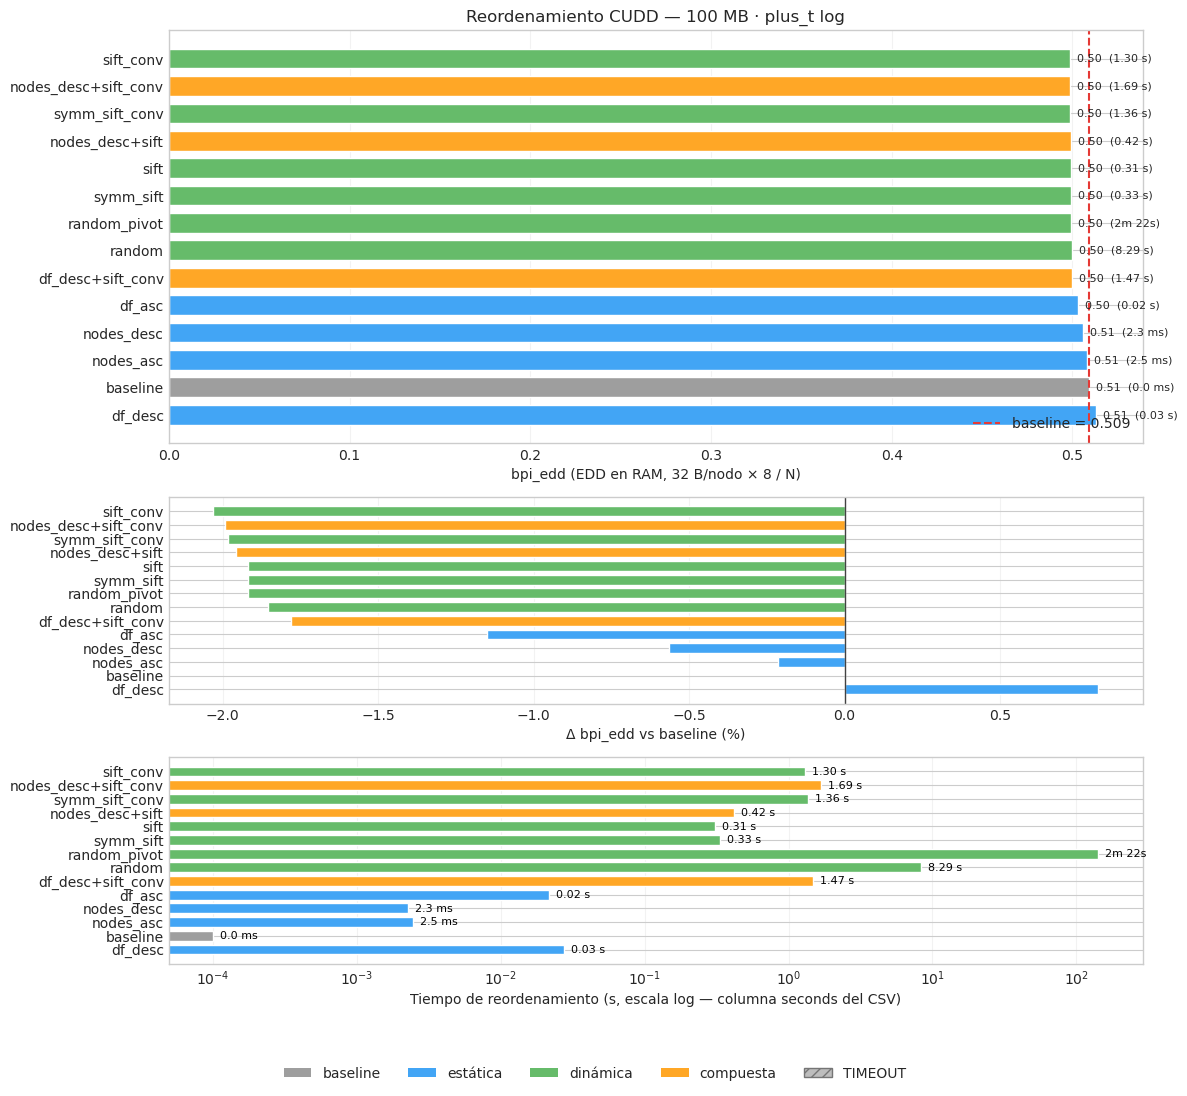

In [ ]:
# ==============================================================================
# 5. Reordenamiento CUDD — bpi_edd por heurística (optimize sweep)
#    Fuente: resultados_test/optimize_sweep_<pack>_<ts>.csv
#    (generado por: zdd_cudd_plus_t optimize sweep log <pack> <docs> [max_sift_vars])
# ==============================================================================
import glob
from pathlib import Path
from matplotlib.patches import Patch

# --- configuración común del barrido ---
MIN_HEURISTICS = 3

CAT_COLORS = {
    'baseline': '#9e9e9e',
    'estática': '#42a5f5',
    'dinámica': '#66bb6a',
    'compuesta': '#ffa726',
}
TIMEOUT_COLOR = '#bdbdbd'
TIMEOUT_EDGE = '#757575'
TIMEOUT_HATCH = '///'


def _heur_categoria(h: str) -> str:
    if h == 'baseline':
        return 'baseline'
    if '+' in h:
        return 'compuesta'
    if h.startswith('nodes_') or h.startswith('df_'):
        return 'estática'
    return 'dinámica'


def _fmt_seconds(s: float) -> str:
    """Formato legible; seconds viene del CSV (chrono en optimize.h)."""
    if s < 0.01:
        return f'{s * 1000:.1f} ms'
    if s < 60:
        return f'{s:.2f} s'
    m, sec = divmod(s, 60)
    return f'{int(m)}m {sec:.0f}s' if m >= 1 else f'{s:.1f} s'


def _load_sweep_for_pack(pack_key: str) -> tuple[pd.DataFrame, str, int]:
    pattern = os.path.join(OUTPUT_DIR, f'optimize_sweep_{pack_key}*.csv')
    candidates = sorted(glob.glob(pattern), key=os.path.getmtime, reverse=True)
    # Prefer COMPLETE if present (canonical merge after resume).
    complete = os.path.join(OUTPUT_DIR, f'optimize_sweep_{pack_key}_COMPLETE.csv')
    if os.path.isfile(complete):
        candidates = [complete] + [p for p in candidates if p != complete]
    best_path, best_df, best_n, best_ok = None, None, 0, -1
    for path in candidates:
        df = pd.read_csv(path)
        n_total = len(df)
        n_ok = int((df['status'] == 'ok').sum()) if 'status' in df.columns else n_total
        # More rows wins; on tie prefer more ok (avoids polluted TIMEOUT overwrites).
        if n_total > best_n or (n_total == best_n and n_ok > best_ok):
            best_n, best_ok, best_path, best_df = n_total, n_ok, path, df
    if best_df is not None and best_n > 0:
        return best_df, best_path, best_n
    return pd.DataFrame(), '', 0


def _bar_color(row) -> str:
    if row.get('status') == 'TIMEOUT':
        return TIMEOUT_COLOR
    return CAT_COLORS.get(row['categoria'], '#ab47bc')


def plot_optimize_sweep(pack_key: str, plot_label: str, docs_basename: str) -> None:
    """Gráfico de barrido optimize sweep para un pack (.zpack sin extensión en pack_key)."""
    swp_all, swp_path, _ = _load_sweep_for_pack(pack_key)
    if swp_all.empty:
        raise FileNotFoundError(
            f'Sin CSV de optimize para {pack_key}. Ejecuta:\n'
            f'  ./zdd_cudd_plus_t optimize sweep log resultados_test/{pack_key}.zpack '
            f'resultados_test/{docs_basename} 200 [timeout_s] [heur...]'
        )
    if 'status' not in swp_all.columns:
        swp_all['status'] = 'ok'

    swp_ok = swp_all[swp_all['status'] == 'ok'].copy()
    swp_to = swp_all[swp_all['status'] == 'TIMEOUT'].copy()
    if swp_ok.empty:
        raise ValueError(f'Sin heurísticas ok en {swp_path}')

    baseline_rows = swp_ok.loc[swp_ok['heuristica'] == 'baseline', 'bpi_edd_after']
    b0 = float(baseline_rows.iloc[0]) if len(baseline_rows) else float(swp_ok['bpi_edd_before'].iloc[0])

    swp_ok['categoria'] = swp_ok['heuristica'].map(_heur_categoria)
    swp_ok['delta_bpi_pct'] = 100.0 * (swp_ok['bpi_edd_after'] - b0) / b0
    swp_ok = swp_ok.sort_values('bpi_edd_after')

    swp_to = swp_to.sort_values('heuristica')
    swp_to['categoria'] = 'timeout'
    swp_to['delta_bpi_pct'] = np.nan

    swp_plot = pd.concat([swp_ok, swp_to], ignore_index=True)
    n_ok, n_to, n_heur = len(swp_ok), len(swp_to), len(swp_plot)

    print(f'Sweep: {swp_path}')
    print(f'Heurísticas ok: {n_ok}  |  TIMEOUT: {n_to}  |  baseline bpi_edd={b0:.4f}')
    if n_to:
        lim = swp_to['seconds'].max()
        print(f'  (TIMEOUT: sin bpi_edd fiable; tiempo ≥ {_fmt_seconds(lim)})')

    if n_ok < MIN_HEURISTICS and n_to == 0:
        print('\n' + '=' * 72)
        print(f'BARRIDO INCOMPLETO ({n_ok} fila(s) ok). Gráfico omitido.')
        print('Ejecuta optimize sweep y vuelve a correr esta celda.')
        print('=' * 72)
        display(swp_all[['heuristica', 'status', 'bpi_edd_after', 'delta_pct', 'seconds']])
        raise SystemExit('Gráfico omitido: barrido incompleto.')
    elif n_ok < MIN_HEURISTICS:
        print(f'AVISO: solo {n_ok} heurística(s) ok (< {MIN_HEURISTICS}); TIMEOUT se muestran aparte.')

    swp_disp = swp_all.copy()
    swp_disp['categoria'] = swp_disp.apply(
        lambda r: 'timeout' if r['status'] == 'TIMEOUT' else _heur_categoria(r['heuristica']), axis=1
    )
    swp_disp['delta_bpi_pct'] = np.where(
        swp_disp['status'] == 'ok',
        100.0 * (swp_disp['bpi_edd_after'] - b0) / b0,
        np.nan,
    )
    display(swp_disp[[
        'heuristica', 'status', 'categoria', 'edd_before', 'edd_after', 'delta_pct',
        'bpi_edd_after', 'delta_bpi_pct', 'seconds'
    ]].style.format({
        'edd_before': '{:,.0f}', 'edd_after': '{:,.0f}',
        'delta_pct': '{:.2f}', 'bpi_edd_after': '{:.4f}',
        'delta_bpi_pct': '{:.2f}', 'seconds': '{:.1f}',
    }, na_rep='—').map(
        lambda v: 'background-color: #ffcdd2' if v == 'TIMEOUT' else '',
        subset=['status'],
    ))

    fig_h = max(8, 0.55 * n_heur + 3)
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(12, fig_h), gridspec_kw={'height_ratios': [2, 1, 1]}
    )
    y_pos = np.arange(n_heur)
    colors = [_bar_color(row) for _, row in swp_plot.iterrows()]
    sec_plot = swp_plot['seconds'].clip(lower=1e-4)

    for i, (_, row) in enumerate(swp_plot.iterrows()):
        is_to = row['status'] == 'TIMEOUT'
        kw = dict(height=0.72, edgecolor='white' if not is_to else TIMEOUT_EDGE)
        if is_to:
            kw.update(color=TIMEOUT_COLOR, hatch=TIMEOUT_HATCH, alpha=0.85)
            ax1.barh(i, b0, **kw)
            ax1.text(b0, i, f'  TIMEOUT ≥ {_fmt_seconds(row["seconds"])}', va='center', fontsize=8, color='#616161')
            ax2.barh(i, 0, **kw)
            ax2.text(0, i, '  TIMEOUT (sin Δ bpi)', va='center', fontsize=8, color='#616161')
        else:
            ax1.barh(i, row['bpi_edd_after'], color=colors[i], **kw)
            ax1.text(
                row['bpi_edd_after'], i,
                f"  {row['bpi_edd_after']:.2f}  ({_fmt_seconds(row['seconds'])})",
                va='center', fontsize=8,
            )
            ax2.barh(i, row['delta_bpi_pct'], color=colors[i], **kw)

        ax3.barh(i, sec_plot.iloc[i], color=colors[i], hatch=TIMEOUT_HATCH if is_to else None,
                 edgecolor=TIMEOUT_EDGE if is_to else 'white', height=0.72, alpha=0.85 if is_to else 1.0)
        ax3.text(sec_plot.iloc[i], i, f"  {_fmt_seconds(row['seconds'])}" + (' TIMEOUT' if is_to else ''),
                 va='center', fontsize=8, color='#616161' if is_to else 'black')

    ax1.axvline(b0, color='#e53935', ls='--', lw=1.5, label=f'baseline = {b0:.3f}')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(swp_plot['heuristica'])
    ax1.set_xlabel('bpi_edd (EDD en RAM, 32 B/nodo × 8 / N)')
    ax1.set_title(f'Reordenamiento CUDD — {plot_label}')
    ax1.invert_yaxis()
    ax1.legend(loc='lower right')
    ax1.grid(True, axis='x', alpha=0.25)

    ax2.axvline(0, color='#424242', lw=1)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(swp_plot['heuristica'])
    ax2.set_xlabel('Δ bpi_edd vs baseline (%)')
    ax2.invert_yaxis()
    ax2.grid(True, axis='x', alpha=0.25)

    ax3.set_xscale('log')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(swp_plot['heuristica'])
    ax3.set_xlabel('Tiempo de reordenamiento (s, escala log — columna seconds del CSV)')
    ax3.invert_yaxis()
    ax3.grid(True, axis='x', alpha=0.25)

    legend_patches = [Patch(facecolor=CAT_COLORS[k], label=k) for k in CAT_COLORS]
    legend_patches.append(Patch(facecolor=TIMEOUT_COLOR, edgecolor=TIMEOUT_EDGE, hatch=TIMEOUT_HATCH, label='TIMEOUT'))
    fig.legend(handles=legend_patches, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    out_png = os.path.join(OUTPUT_DIR, f'optimize_sweep_{pack_key}_bpi.png')
    plt.savefig(out_png, dpi=120, bbox_inches='tight')
    print(f'Gráfico guardado: {out_png}')
    plt.show()


# --- 100 MB ---
plot_optimize_sweep('wiki_100mb_plus_t', '100 MB · plus_t log', 'wiki_100mb_uihrdc_packed64.docs')

Sweep: resultados_test/optimize_sweep_wiki_2gb_plus_t_bin_20260802_183133.csv
Heurísticas ok: 2  |  TIMEOUT: 4  |  baseline bpi_edd=35.4710
  (TIMEOUT: sin bpi_edd fiable; tiempo ≥ 20m 0s)
AVISO: solo 2 heurística(s) ok (< 3); TIMEOUT se muestran aparte.


,heuristica,status,categoria,edd_before,edd_after,delta_pct,bpi_edd_after,delta_bpi_pct,seconds
0,baseline,ok,baseline,"16,931,565","16,931,565",0.00,35.4710,0.00,0.0
1,df_desc,ok,estática,"16,931,565","16,307,549",-3.69,34.1637,-3.69,997.0
2,df_asc,TIMEOUT,timeout,"16,931,565","16,931,565",0.00,35.4710,—,1200.0
3,sift,TIMEOUT,timeout,"16,931,565","16,931,565",0.00,35.4710,—,1200.0
4,sift_conv,TIMEOUT,timeout,"16,931,565","16,931,565",0.00,35.4710,—,1200.0
5,symm_sift_conv,TIMEOUT,timeout,"16,931,565","16,931,565",0.00,35.4710,—,1200.0


Gráfico guardado: resultados_test/optimize_sweep_wiki_2gb_plus_t_bin_bpi.png


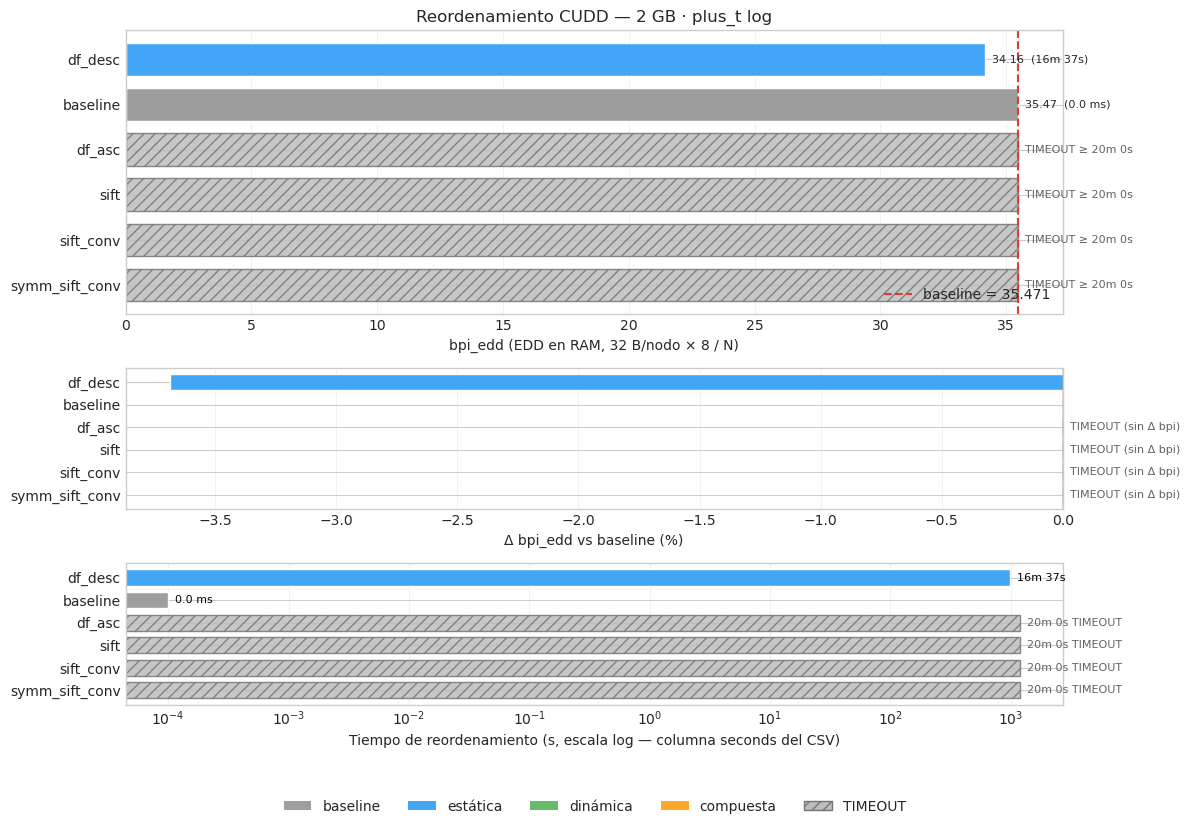

In [ ]:
# ==============================================================================
# 6. Reordenamiento CUDD — 2 GB (misma función que celda 5)
#    CSV: optimize_sweep_wiki_2gb_plus_t_bin_*.csv
# ==============================================================================
plot_optimize_sweep(
    'wiki_2gb_plus_t_bin',
    '2 GB · plus_t log',
    'wiki_2gb_uihrdc_packed64.docs',
)

In [ ]:
# ==============================================================================
# 7. Reordenamiento CUDD — 1 GB (misma función que celda 5)
#    CSV: optimize_sweep_wiki_1gb_plus_t_bin_*.csv
# ==============================================================================
plot_optimize_sweep(
    'wiki_1gb_plus_t_bin',
    '1 GB · plus_t log',
    'wiki_1gb_uihrdc_packed64.docs',
)